# Human Activity Recognition from Smartphone Sensors
## Stages 1, 2 & 3: Problem Definition · Data Collection · Preprocessing

**Dataset:** UCI HAR Dataset  
**Goal:** Classify physical activities (walking, sitting, standing, running, stair climbing)  
from accelerometer and gyroscope data.

---

## Table of Contents
1. [Stage 1 – Problem Definition & Literature Review](#stage1)
2. [Stage 2 – Data Collection & Data Understanding](#stage2)
3. [Stage 3 – Data Preprocessing & Cleaning](#stage3)

---
# Stage 1 – Problem Definition & Literature Review <a id='stage1'></a>

## 1.1 Problem Statement

**Human Activity Recognition (HAR)** is the task of automatically identifying what physical activity a person is performing based on sensor readings collected from a smartphone worn on the body (typically at the waist).

### Activities to Classify
| Label | Activity |
|-------|----------|
| 1 | Walking |
| 2 | Walking Upstairs |
| 3 | Walking Downstairs |
| 4 | Sitting |
| 5 | Standing |
| 6 | Laying |

### Sensors Used
- **Accelerometer** – measures linear acceleration in 3 axes (X, Y, Z)
- **Gyroscope** – measures angular velocity in 3 axes

### Why This Matters
- **Healthcare:** Remote patient monitoring, rehabilitation tracking
- **Fitness:** Automatic workout logging on smartphones and smartwatches
- **Elderly Care:** Fall detection and daily activity monitoring
- **Sports Science:** Athlete performance analysis

## 1.2 Project Objectives

1. **Feature Engineering** – Extract time-domain and frequency-domain statistical features from sliding windows of raw sensor signals.
2. **Classical ML Models** – Train and tune **SVM** and **Random Forest** classifiers on handcrafted features.
3. **Deep Learning Model** – Train a **LSTM** (Long Short-Term Memory) network directly on raw sequential sensor data.
4. **Comparison** – Compare handcrafted feature pipelines vs. end-to-end deep learning.
5. **Generalization** – Evaluate all models on held-out **unseen subjects** (person-independent test split).

## 1.3 Literature Review

### Foundational Work

**Anguita et al. (2013)** introduced the UCI HAR dataset. Their pipeline used a **561-dimensional feature vector** extracted from 2.56-second sliding windows (50% overlap) over triaxial accelerometer and gyroscope signals. They trained a **Multiclass SVM** and reported **~89% accuracy** on the test set. This established the benchmark for classical ML on HAR.

**Wang et al. (2019)** — *Deep Learning for Sensor-Based Activity Recognition: A Survey* — surveyed deep learning methods including CNN, LSTM, and hybrid CNN-LSTM architectures. Key finding: deep models eliminate the need for manual feature engineering and can learn hierarchical temporal representations, consistently outperforming classical ML by 5–10% on public benchmarks.

**Ordóñez & Roggen (2016)** proposed **DeepConvLSTM**, a deep network combining convolutional and recurrent layers for HAR. Achieved state-of-the-art at the time on Opportunity and PAMAP2 datasets. Demonstrated that raw sensor input + deep architecture matches or beats handcrafted pipelines.

**Ronao & Cho (2016)** applied a **CNN directly** to UCI HAR raw signals. Achieved **94.79% accuracy** — substantially higher than classical SVM on the same dataset, confirming the advantage of learned representations.

### Key Insights from Literature

| Approach | Typical Accuracy (UCI HAR) | Feature Type |
|----------|---------------------------|---------------|
| SVM (561 features) | ~89% | Handcrafted |
| Random Forest | ~91% | Handcrafted |
| LSTM | ~92–93% | Raw sequences |
| CNN | ~94–95% | Raw sequences |
| CNN-LSTM hybrid | ~95–96% | Raw sequences |

### Challenges Identified
- **Subject variability:** Different people perform the same activity differently (gait, pace, phone placement).
- **Transition states:** The boundary between activities (e.g., transitioning from walking to sitting) is ambiguous.
- **Static vs. dynamic activities:** Sitting and standing are easily confused as both produce near-zero acceleration.
- **Generalization:** Models trained on specific subjects may not generalize — person-independent evaluation is essential.

## 1.4 Proposed Pipeline

```
Raw Sensor Data (Accelerometer + Gyroscope)
         │
         ▼
   Sliding Windows (2.56s, 50% overlap)
         │
   ┌─────┴──────┐
   │            │
   ▼            ▼
Handcrafted   Raw Sequences
Features      (for LSTM)
(561-dim)         │
   │              ▼
   │           LSTM Model
   │
   ├──► SVM Classifier
   └──► Random Forest
         │
         ▼
  Evaluation on Unseen Subjects
  (Accuracy, F1, Confusion Matrix)
```

In [1]:
# Stage 1 – Library Imports & Environment Check
import sys
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("=== Environment Check ===")
print(f"Python  : {sys.version.split()[0]}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

try:
    import tensorflow as tf
    print(f"TensorFlow: {tf.__version__}")
except ImportError:
    print("TensorFlow: not installed (run: pip install tensorflow)")

=== Environment Check ===
Python  : 3.12.13
NumPy   : 2.0.2
Pandas  : 2.2.2
Matplotlib: 3.10.0
Scikit-learn: 1.6.1
TensorFlow: 2.20.0


In [2]:
# ─── Global Configuration ───────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── Dataset paths (update DATA_ROOT if needed) ──
DATA_ROOT   = 'UCI HAR Dataset'          # top-level folder after unzipping
TRAIN_PATH  = os.path.join(DATA_ROOT, 'train')
TEST_PATH   = os.path.join(DATA_ROOT, 'test')

# ── Signal windowing parameters (matching original paper) ──
WINDOW_SIZE  = 128    # samples per window  (2.56 s @ 50 Hz)
OVERLAP      = 64     # 50% overlap
SAMPLE_RATE  = 50     # Hz

# ── Activity label mapping ──
ACTIVITY_MAP = {
    1: 'Walking',
    2: 'Walking Upstairs',
    3: 'Walking Downstairs',
    4: 'Sitting',
    5: 'Standing',
    6: 'Laying'
}

# ── Sensor channel names ──
SIGNAL_NAMES = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
]

RANDOM_STATE = 42
print("Configuration loaded.")
print(f"Data root : {DATA_ROOT}")
print(f"Window    : {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLE_RATE:.2f}s)")
print(f"Overlap   : {OVERLAP} samples (50%)")

Configuration loaded.
Data root : UCI HAR Dataset
Window    : 128 samples (2.56s)
Overlap   : 64 samples (50%)


---
# Stage 2 – Data Collection & Data Understanding <a id='stage2'></a>

## 2.1 Dataset Overview

### UCI HAR Dataset
- **Source:** UC Irvine Machine Learning Repository  
  https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones
- **Subjects:** 30 volunteers aged 19–48 years
- **Device:** Samsung Galaxy S II worn at the waist
- **Sampling Rate:** 50 Hz
- **Window:** 2.56 seconds, 50% overlap → 128 readings per window
- **Split:** 70% training (21 subjects), 30% testing (9 subjects)

### Data Files Structure
```
UCI HAR Dataset/
├── activity_labels.txt          ← 6 class labels
├── features.txt                 ← 561 feature names
├── features_info.txt            ← Feature descriptions
├── train/
│   ├── X_train.txt              ← 7352 × 561 pre-computed features
│   ├── y_train.txt              ← 7352 labels
│   ├── subject_train.txt        ← subject ID per sample
│   └── Inertial Signals/        ← raw sensor windows
│       ├── body_acc_x_train.txt  (7352 × 128)
│       ├── body_acc_y_train.txt
│       ├── body_acc_z_train.txt
│       ├── body_gyro_x_train.txt
│       ├── body_gyro_y_train.txt
│       ├── body_gyro_z_train.txt
│       ├── total_acc_x_train.txt
│       ├── total_acc_y_train.txt
│       └── total_acc_z_train.txt
└── test/
    └── (same structure as train)
```

In [7]:
import urllib.request
import zipfile
import os
import shutil

UCI_URL  = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
ZIP_PATH = 'har_dataset.zip' # This might get overwritten if 'UCI HAR Dataset.zip' is found.

# Flag to track if download/extraction happened
data_extracted = False

# Ensure that the dataset zip file exists and is extracted.
# The URL gives the file name 'UCI HAR Dataset.zip' upon download.
if os.path.exists('UCI HAR Dataset.zip'):
    print("Found existing 'UCI HAR Dataset.zip', extracting...")
    ZIP_PATH = 'UCI HAR Dataset.zip'
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')
    os.remove(ZIP_PATH)
    print("Extraction complete.")
    data_extracted = True
elif not os.path.exists(DATA_ROOT): # If DATA_ROOT (the folder) doesn't exist, download and extract
    print("Downloading UCI HAR Dataset (~60 MB)...")
    # Make sure to name the downloaded file consistently to avoid issues
    urllib.request.urlretrieve(UCI_URL, 'UCI HAR Dataset.zip') # Save with correct name
    ZIP_PATH = 'UCI HAR Dataset.zip'
    print("Download complete. Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')
    os.remove(ZIP_PATH)
    print("Extraction complete.")
    data_extracted = True
else:
    print(f"Dataset already present at '{DATA_ROOT}'.")
    # Even if DATA_ROOT exists, ensure it's properly structured
    if not os.path.exists(os.path.join(DATA_ROOT, 'train', 'X_train.txt')):
        print(f"Warning: '{DATA_ROOT}' exists but data files are not found within it. Re-checking structure.")
        data_extracted = True # Force re-evaluation of data_extracted for structure fix

# Robustly find and set the correct DATA_ROOT after extraction
if data_extracted:
    # Check if the expected DATA_ROOT already contains the files
    if os.path.exists(os.path.join(DATA_ROOT, 'train', 'X_train.txt')):
        print(f"Dataset found correctly structured at '{DATA_ROOT}'.")
    else:
        # Search for the actual dataset root in case of nested extraction or different name
        actual_data_root_found = None
        for root, dirs, files in os.walk('.'):
            if 'features.txt' in files and 'train' in dirs and 'test' in dirs:
                actual_data_root_found = root
                break

        if actual_data_root_found and os.path.relpath(actual_data_root_found, '.') != DATA_ROOT:
            print(f"Data found at '{actual_data_root_found}'. Moving to expected '{DATA_ROOT}'...")
            if os.path.exists(DATA_ROOT):
                shutil.rmtree(DATA_ROOT) # Remove potentially empty/incorrect DATA_ROOT
            shutil.move(actual_data_root_found, DATA_ROOT)
            print("Data directory corrected.")
        elif not actual_data_root_found:
            print(f"Warning: Could not find the expected dataset structure ('train', 'test' directories and 'features.txt' file) within current directory or its subfolders.")
            print("Attempting to fix common nested directory issue (e.g., 'UCI HAR Dataset/UCI HAR Dataset')...")
            # This handles the specific case of DATA_ROOT/DATA_ROOT
            if os.path.isdir(os.path.join(DATA_ROOT, DATA_ROOT)):
                print(f"Detected nested directory '{DATA_ROOT}/{DATA_ROOT}'. Correcting...")
                nested_path = os.path.join(DATA_ROOT, DATA_ROOT)
                if os.path.exists(DATA_ROOT) and os.path.samefile(os.path.abspath(DATA_ROOT), os.path.abspath(nested_path)):
                    # This means DATA_ROOT is actually the nested_path, so don't delete
                    pass
                elif os.path.exists(DATA_ROOT):
                    shutil.rmtree(DATA_ROOT)
                shutil.move(nested_path, DATA_ROOT)
                print(f"Data directory corrected to '{DATA_ROOT}'.")
            else:
                print(f"Please manually verify the extracted data structure. Expected at '{DATA_ROOT}'.")
        else: # actual_data_root_found exists and os.path.relpath == DATA_ROOT
            print(f"Dataset found correctly structured at '{DATA_ROOT}'.")

# Re-evaluate TRAIN_PATH and TEST_PATH as DATA_ROOT might have been corrected
TRAIN_PATH  = os.path.join(DATA_ROOT, 'train')
TEST_PATH   = os.path.join(DATA_ROOT, 'test')

Found existing 'UCI HAR Dataset.zip', extracting...
Extraction complete.
Dataset found correctly structured at 'UCI HAR Dataset'.


In [8]:
# ─── Load Pre-computed Feature Vectors (561-dim) ─────────────────────────────
import numpy as np
import pandas as pd

def load_har_features(data_root='UCI HAR Dataset'):
    """Load the 561-dimensional pre-computed feature matrices."""
    X_train = pd.read_csv(
        os.path.join(data_root, 'train', 'X_train.txt'),
        sep='\s+', header=None
    ).values
    X_test = pd.read_csv(
        os.path.join(data_root, 'test', 'X_test.txt'),
        sep='\s+', header=None
    ).values

    y_train = pd.read_csv(
        os.path.join(data_root, 'train', 'y_train.txt'),
        header=None
    ).values.ravel()
    y_test = pd.read_csv(
        os.path.join(data_root, 'test', 'y_test.txt'),
        header=None
    ).values.ravel()

    subj_train = pd.read_csv(
        os.path.join(data_root, 'train', 'subject_train.txt'),
        header=None
    ).values.ravel()
    subj_test = pd.read_csv(
        os.path.join(data_root, 'test', 'subject_test.txt'),
        header=None
    ).values.ravel()

    features = pd.read_csv(
        os.path.join(data_root, 'features.txt'),
        sep='\s+', header=None
    )[1].tolist()

    return X_train, X_test, y_train, y_test, subj_train, subj_test, features

X_train, X_test, y_train, y_test, subj_train, subj_test, feature_names = \
    load_har_features(DATA_ROOT)

print("=== Feature Data Loaded ===")
print(f"X_train shape : {X_train.shape}   (samples × features)")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test  shape : {y_test.shape}")
print(f"Number of features : {len(feature_names)}")
print(f"Training subjects  : {sorted(np.unique(subj_train))}")
print(f"Test subjects      : {sorted(np.unique(subj_test))}")

=== Feature Data Loaded ===
X_train shape : (7352, 561)   (samples × features)
X_test  shape : (2947, 561)
y_train shape : (7352,)
y_test  shape : (2947,)
Number of features : 561
Training subjects  : [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test subjects      : [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]


In [9]:
# ─── Load Raw Inertial Signals ───────────────────────────────────────────────
def load_raw_signals(split_path, signal_names):
    """Load all 9 raw sensor channels → ndarray (samples, timesteps, channels)."""
    inertial_path = os.path.join(split_path, 'Inertial Signals')
    split_tag = 'train' if 'train' in split_path else 'test'
    signals = []
    for name in signal_names:
        fpath = os.path.join(inertial_path, f'{name}_{split_tag}.txt')
        arr = pd.read_csv(fpath, sep='\s+', header=None).values
        signals.append(arr)
    return np.stack(signals, axis=-1)   # → (N, 128, 9)

print("Loading raw inertial signals (this may take ~30 seconds)...")
X_raw_train = load_raw_signals(TRAIN_PATH, SIGNAL_NAMES)
X_raw_test  = load_raw_signals(TEST_PATH,  SIGNAL_NAMES)

print(f"X_raw_train shape : {X_raw_train.shape}   (samples, timesteps, channels)")
print(f"X_raw_test  shape : {X_raw_test.shape}")
print(f"Channels          : {SIGNAL_NAMES}")

Loading raw inertial signals (this may take ~30 seconds)...
X_raw_train shape : (7352, 128, 9)   (samples, timesteps, channels)
X_raw_test  shape : (2947, 128, 9)
Channels          : ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


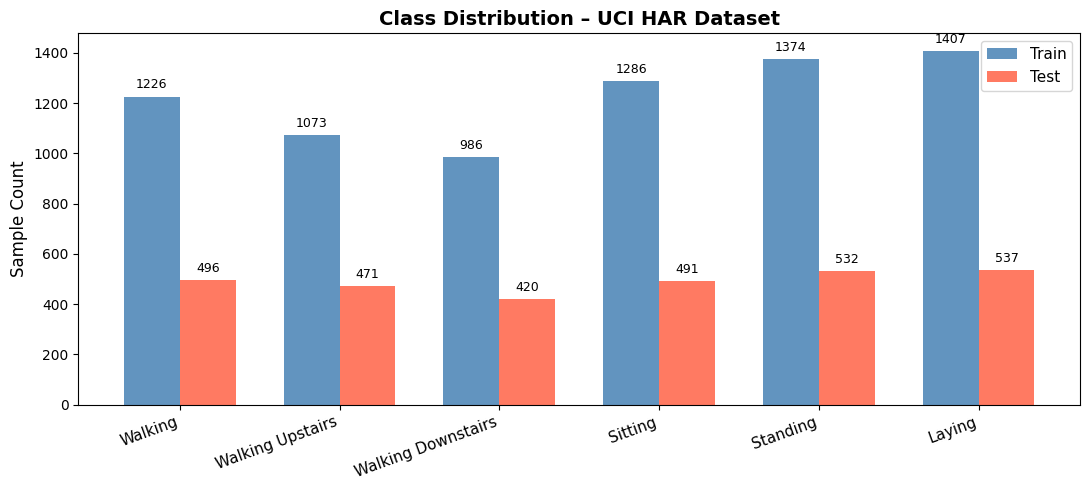

Saved: stage2_class_distribution.png

--- Train class counts ---
  Walking                :  1226
  Walking Upstairs       :  1073
  Walking Downstairs     :   986
  Sitting                :  1286
  Standing               :  1374
  Laying                 :  1407

--- Test class counts ---
  Walking                :   496
  Walking Upstairs       :   471
  Walking Downstairs     :   420
  Sitting                :   491
  Standing               :   532
  Laying                 :   537


In [10]:
# ─── Class Distribution Analysis ─────────────────────────────────────────────
import matplotlib.pyplot as plt

def plot_class_distribution(y_train, y_test, activity_map):
    labels = [activity_map[i] for i in sorted(activity_map)]
    train_counts = [np.sum(y_train == i) for i in sorted(activity_map)]
    test_counts  = [np.sum(y_test  == i) for i in sorted(activity_map)]

    x = np.arange(len(labels))
    w = 0.35

    fig, ax = plt.subplots(figsize=(11, 5))
    bars1 = ax.bar(x - w/2, train_counts, w, label='Train', color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + w/2, test_counts,  w, label='Test',  color='tomato',    alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=11)
    ax.set_ylabel('Sample Count', fontsize=12)
    ax.set_title('Class Distribution – UCI HAR Dataset', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('stage2_class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: stage2_class_distribution.png")

plot_class_distribution(y_train, y_test, ACTIVITY_MAP)

# Print counts
print("\n--- Train class counts ---")
for k, v in ACTIVITY_MAP.items():
    print(f"  {v:<22} : {np.sum(y_train == k):>5}")
print("\n--- Test class counts ---")
for k, v in ACTIVITY_MAP.items():
    print(f"  {v:<22} : {np.sum(y_test == k):>5}")

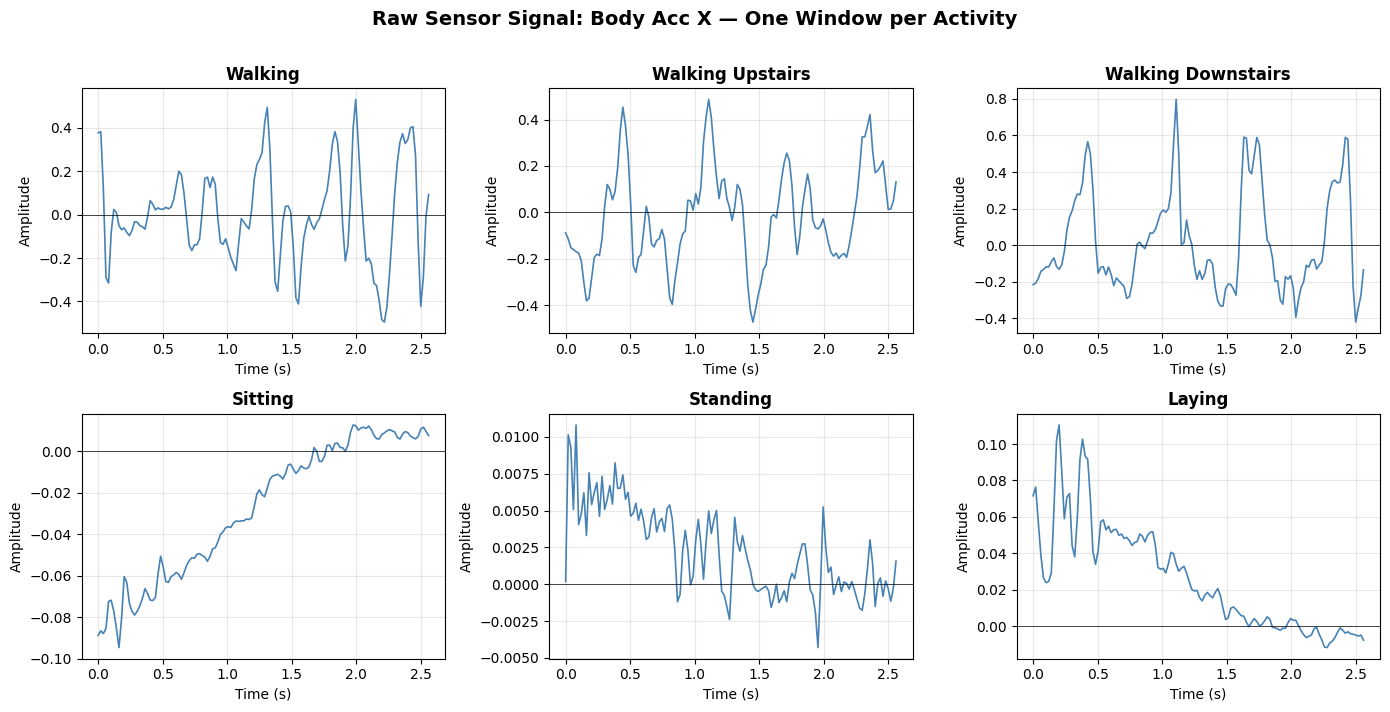

Saved: stage2_raw_signals.png


In [11]:
# ─── Visualise Raw Sensor Signals per Activity ───────────────────────────────
def plot_raw_signals_per_activity(X_raw, y, activity_map, channel=0, channel_name='Body Acc X'):
    """
    Plot one representative window of a sensor channel for each activity.
    channel: index into the 9-channel axis
    """
    activities = sorted(activity_map.keys())
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
    axes = axes.flatten()

    t = np.linspace(0, WINDOW_SIZE / SAMPLE_RATE, WINDOW_SIZE)

    for ax, act_id in zip(axes, activities):
        idx = np.where(y == act_id)[0][0]      # first matching sample
        signal = X_raw[idx, :, channel]
        ax.plot(t, signal, color='steelblue', linewidth=1.2)
        ax.set_title(activity_map[act_id], fontsize=12, fontweight='bold')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='k', linewidth=0.5)

    fig.suptitle(f'Raw Sensor Signal: {channel_name} — One Window per Activity',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('stage2_raw_signals.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: stage2_raw_signals.png")

plot_raw_signals_per_activity(X_raw_train, y_train, ACTIVITY_MAP,
                               channel=0, channel_name='Body Acc X')

In [12]:
# ─── Subject-Level Analysis ───────────────────────────────────────────────────
print("=== Subject-Level Summary ===")
for split, y, subj in [('Train', y_train, subj_train), ('Test', y_test, subj_test)]:
    subj_ids = sorted(np.unique(subj))
    print(f"\n{split} split — {len(subj_ids)} subjects: {subj_ids}")

# Verify no subject overlap between train and test
overlap = set(subj_train) & set(subj_test)
print(f"\nSubject overlap between train & test: {overlap if overlap else 'None ✓'}")
print("→ Person-independent evaluation is guaranteed.")

# Samples per subject (train)
subj_counts_df = pd.DataFrame({'subject': subj_train, 'label': y_train})
print("\nSamples per training subject:")
print(subj_counts_df.groupby('subject')['label'].count().to_string())

=== Subject-Level Summary ===

Train split — 21 subjects: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Test split — 9 subjects: [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]

Subject overlap between train & test: None ✓
→ Person-independent evaluation is guaranteed.

Samples per training subject:
subject
1     347
3     341
5     302
6     325
7     308
8     281
11    316
14    323
15    328
16    366
17    368
19    360
21    408
22    321
23    372
25    409
26    392
27    376
28    382
29    344
30    383


In [13]:
# ─── Feature Vector Peek ───────────────────────────────────────────────────────
df_features = pd.DataFrame(X_train, columns=feature_names)
df_features['activity'] = y_train
df_features['activity_name'] = df_features['activity'].map(ACTIVITY_MAP)

print("=== Feature DataFrame (first 5 rows, first 10 features) ===")
display(df_features.iloc[:5, :10])

print("\n=== Descriptive Statistics (first 10 features) ===")
display(df_features.iloc[:, :10].describe().round(4))

=== Feature DataFrame (first 5 rows, first 10 features) ===


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469



=== Descriptive Statistics (first 10 features) ===


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X
count,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000
mean,0.2745,-0.0177,-0.1091,-0.6054,-0.5109,-0.6048,-0.6305,-0.5269,-0.6062,-0.4686
std,0.0703,0.0408,0.0566,0.4487,0.5026,0.4187,0.4241,0.4859,0.4141,0.5445
min,-1.0000,-1.0000,-1.0000,-1.0000,-0.9999,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000
25%,0.2630,-0.0249,-0.1210,-0.9928,-0.9781,-0.9802,-0.9936,-0.9782,-0.9803,-0.9362
50%,0.2772,-0.0172,-0.1087,-0.9462,-0.8519,-0.8594,-0.9507,-0.8573,-0.8571,-0.8816
75%,0.2885,-0.0108,-0.0978,-0.2428,-0.0342,-0.2624,-0.2927,-0.0667,-0.2657,-0.0171
max,1.0000,1.0000,1.0000,1.0000,0.9162,1.0000,1.0000,0.9677,1.0000,1.0000


Top 20 features by variance:
   1. fBodyAccJerk-entropy()-X                 (var=0.5651)
   2. fBodyAccJerk-entropy()-Y                 (var=0.5425)
   3. tBodyAccJerkMag-entropy()                (var=0.5289)
   4. fBodyAcc-entropy()-X                     (var=0.5257)
   5. tGravityAcc-correlation()-X,Z            (var=0.5009)
   6. tGravityAcc-correlation()-Y,Z            (var=0.4958)
   7. tBodyGyroJerkMag-entropy()               (var=0.4952)
   8. tGravityAcc-energy()-X                   (var=0.4871)
   9. tGravityAcc-correlation()-X,Y            (var=0.4853)
  10. fBodyAccMag-entropy()                    (var=0.4661)
  11. tGravityAccMag-entropy()                 (var=0.4580)
  12. tBodyAccMag-entropy()                    (var=0.4580)
  13. fBodyBodyAccJerkMag-entropy()            (var=0.4490)
  14. fBodyAcc-entropy()-Y                     (var=0.4484)
  15. tBodyAccJerk-entropy()-X                 (var=0.4267)
  16. fBodyAccJerk-entropy()-Z                 (var=0.4152)
  17. tBody

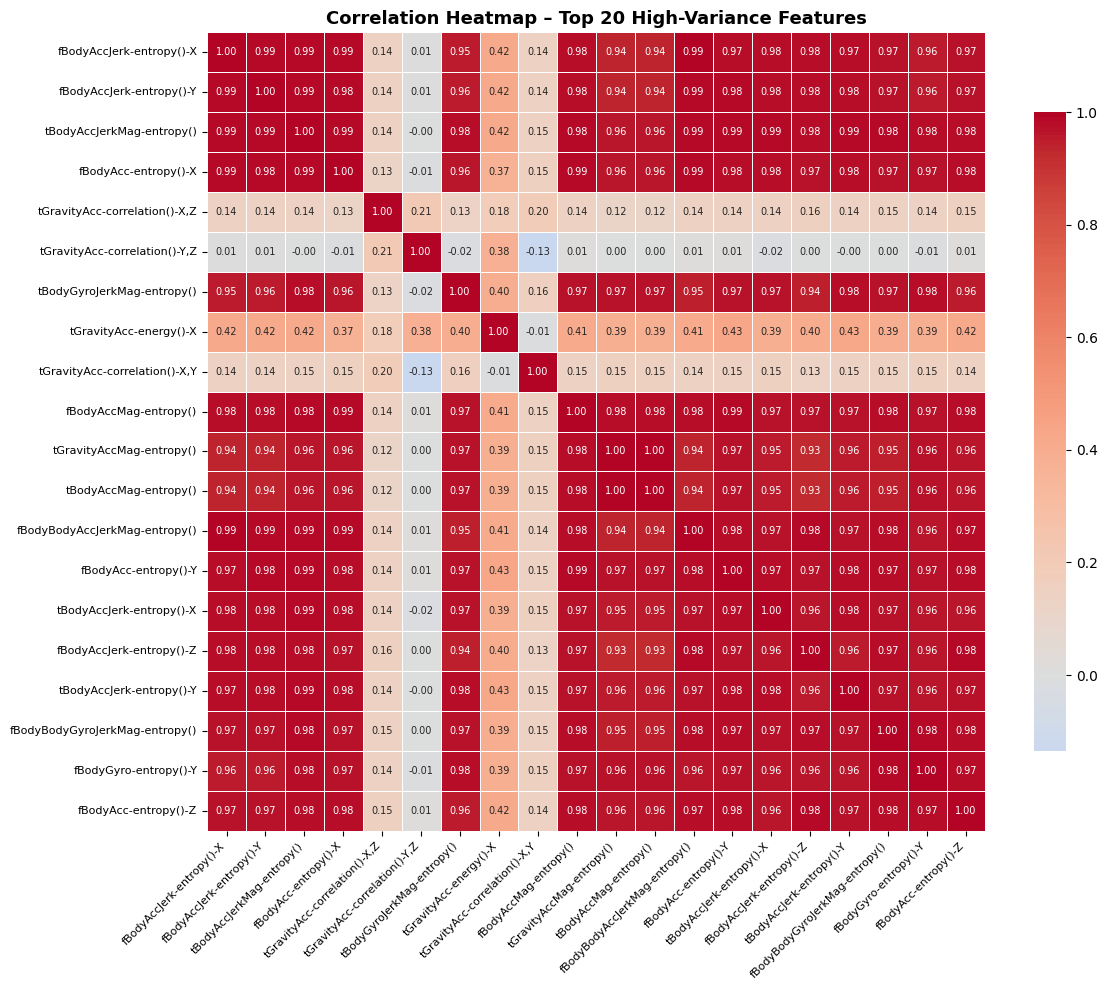

Saved: stage2_correlation_heatmap.png


In [14]:
# ─── Correlation Heatmap (Top 20 Features) ───────────────────────────────────
import seaborn as sns

# Pick top 20 features by variance
variances = df_features.iloc[:, :-2].var().sort_values(ascending=False)
top20_feat = variances.head(20).index.tolist()

print(f"Top 20 features by variance:")
for i, feat in enumerate(top20_feat, 1):
    print(f"  {i:2d}. {feat:<40} (var={variances[feat]:.4f})")

corr_matrix = df_features[top20_feat].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap – Top 20 High-Variance Features',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('stage2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage2_correlation_heatmap.png")

In [15]:
# ─── Missing Value & Data Quality Check ──────────────────────────────────────
print("=== Data Quality Report ===")
for name, arr in [('X_train', X_train), ('X_test', X_test),
                  ('X_raw_train', X_raw_train), ('X_raw_test', X_raw_test)]:
    nans = np.sum(np.isnan(arr))
    infs = np.sum(np.isinf(arr))
    print(f"{name:<20} | shape={str(arr.shape):<22} "
          f"| NaN={nans:>4} | Inf={infs:>4}")

print("\n=== Label Quality ===")
print(f"y_train unique values : {np.unique(y_train)}")
print(f"y_test  unique values : {np.unique(y_test)}")
print(f"All expected labels present: "
      f"{set(np.unique(y_train)) == set(ACTIVITY_MAP.keys())}")

=== Data Quality Report ===
X_train              | shape=(7352, 561)            | NaN=   0 | Inf=   0
X_test               | shape=(2947, 561)            | NaN=   0 | Inf=   0
X_raw_train          | shape=(7352, 128, 9)         | NaN=   0 | Inf=   0
X_raw_test           | shape=(2947, 128, 9)         | NaN=   0 | Inf=   0

=== Label Quality ===
y_train unique values : [1 2 3 4 5 6]
y_test  unique values : [1 2 3 4 5 6]
All expected labels present: True


---
# Stage 3 – Data Preprocessing & Cleaning <a id='stage3'></a>

## 3.1 Preprocessing Strategy

The UCI HAR dataset is already windowed and reasonably clean. However, we must apply proper preprocessing for each model pathway:

| Step | Classical ML (SVM/RF) | Deep Learning (LSTM) |
|------|-----------------------|----------------------|
| Input | 561-dim feature vector | Raw signals (128, 9) |
| Normalization | StandardScaler per feature | Per-channel min-max or z-score |
| Label encoding | y as integers (1–6) | y one-hot encoded |
| Duplicate removal | ✓ | ✓ |
| Missing value handling | Fill/drop (none found) | Fill/drop (none found) |
| Feature deduplication | Remove duplicate columns | N/A |

In [16]:
# ─── Step 3.1: Remove Duplicate Feature Columns ──────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np

df_train_feat = pd.DataFrame(X_train, columns=feature_names)
df_test_feat  = pd.DataFrame(X_test,  columns=feature_names)

# Identify duplicate column names (UCI HAR has some duplicates)
dup_cols = df_train_feat.columns[df_train_feat.columns.duplicated()].unique().tolist()
print(f"Duplicate column names found: {len(dup_cols)}")
if dup_cols:
    print(f"  → {dup_cols[:10]} ...")  # show first 10

# Keep first occurrence of each duplicated name
df_train_clean = df_train_feat.loc[:, ~df_train_feat.columns.duplicated()]
df_test_clean  = df_test_feat.loc[:,  ~df_test_feat.columns.duplicated()]

print(f"\nFeature count before dedup : {df_train_feat.shape[1]}")
print(f"Feature count after  dedup : {df_train_clean.shape[1]}")

Duplicate column names found: 42
  → ['fBodyAcc-bandsEnergy()-1,8', 'fBodyAcc-bandsEnergy()-9,16', 'fBodyAcc-bandsEnergy()-17,24', 'fBodyAcc-bandsEnergy()-25,32', 'fBodyAcc-bandsEnergy()-33,40', 'fBodyAcc-bandsEnergy()-41,48', 'fBodyAcc-bandsEnergy()-49,56', 'fBodyAcc-bandsEnergy()-57,64', 'fBodyAcc-bandsEnergy()-1,16', 'fBodyAcc-bandsEnergy()-17,32'] ...

Feature count before dedup : 561
Feature count after  dedup : 477


In [17]:
# ─── Step 3.2: Remove Duplicate Rows ─────────────────────────────────────────
df_train_clean['_label'] = y_train
df_test_clean['_label']  = y_test

n_before_train = len(df_train_clean)
n_before_test  = len(df_test_clean)

df_train_clean = df_train_clean.drop_duplicates()
df_test_clean  = df_test_clean.drop_duplicates()

y_train_clean  = df_train_clean['_label'].values
y_test_clean   = df_test_clean['_label'].values

df_train_clean = df_train_clean.drop(columns=['_label'])
df_test_clean  = df_test_clean.drop(columns=['_label'])

print(f"Train rows before: {n_before_train} → after: {len(df_train_clean)} "
      f"(removed: {n_before_train - len(df_train_clean)})")
print(f"Test  rows before: {n_before_test}  → after: {len(df_test_clean)} "
      f"(removed: {n_before_test - len(df_test_clean)})")

Train rows before: 7352 → after: 7352 (removed: 0)
Test  rows before: 2947  → after: 2947 (removed: 0)


In [18]:


# ─── Step 3.3: StandardScaler for Classical ML ───────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler_ml = StandardScaler()

X_train_scaled = scaler_ml.fit_transform(df_train_clean.values)
X_test_scaled  = scaler_ml.transform(df_test_clean.values)

print("=== StandardScaler Applied ===")
print(f"Train → mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"Test  → mean={X_test_scaled.mean():.4f},  std={X_test_scaled.std():.4f}")
print(f"\nX_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled  shape : {X_test_scaled.shape}")

=== StandardScaler Applied ===
Train → mean=0.0000, std=1.0000
Test  → mean=-0.0058,  std=0.9417

X_train_scaled shape : (7352, 477)
X_test_scaled  shape : (2947, 477)


In [19]:
# ─── Step 3.4: Label Encoding ─────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(list(ACTIVITY_MAP.keys()))

# For classical ML: zero-indexed labels (0–5)
y_train_enc = le.transform(y_train_clean)
y_test_enc  = le.transform(y_test_clean)

print("=== Label Encoding ===")
print(f"Original labels  : {np.unique(y_train_clean)}")
print(f"Encoded labels   : {np.unique(y_train_enc)}")
print("Mapping:")
for orig, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {orig} ({ACTIVITY_MAP[orig]}) → {enc}")

=== Label Encoding ===
Original labels  : [1 2 3 4 5 6]
Encoded labels   : [0 1 2 3 4 5]
Mapping:
  1 (Walking) → 0
  2 (Walking Upstairs) → 1
  3 (Walking Downstairs) → 2
  4 (Sitting) → 3
  5 (Standing) → 4
  6 (Laying) → 5


In [20]:
# ─── Step 3.5: Normalize Raw Signals for LSTM ────────────────────────────────
# Z-score normalize each channel independently across the training set
# Shape: (N, 128, 9)

# Compute per-channel mean & std from training data
channel_mean = X_raw_train.mean(axis=(0, 1), keepdims=True)   # (1, 1, 9)
channel_std  = X_raw_train.std(axis=(0, 1),  keepdims=True)   # (1, 1, 9)

# Avoid division by zero
channel_std = np.where(channel_std == 0, 1.0, channel_std)

X_raw_train_norm = (X_raw_train - channel_mean) / channel_std
X_raw_test_norm  = (X_raw_test  - channel_mean) / channel_std  # apply TRAIN stats

print("=== Raw Signal Normalization ===")
print(f"Per-channel means (train): {channel_mean.flatten().round(4)}")
print(f"Per-channel stds  (train): {channel_std.flatten().round(4)}")
print(f"\nX_raw_train_norm → mean={X_raw_train_norm.mean():.4f}, std={X_raw_train_norm.std():.4f}")
print(f"X_raw_test_norm  → mean={X_raw_test_norm.mean():.4f},  std={X_raw_test_norm.std():.4f}")

=== Raw Signal Normalization ===
Per-channel means (train): [-6.000e-04 -3.000e-04 -3.000e-04  5.000e-04 -8.000e-04  1.000e-04
  8.047e-01  2.880e-02  8.650e-02]
Per-channel stds  (train): [0.1948 0.1224 0.1069 0.4068 0.3819 0.2557 0.4141 0.391  0.3578]

X_raw_train_norm → mean=-0.0000, std=1.0000
X_raw_test_norm  → mean=-0.0072,  std=0.9534


In [24]:
# ─── Step 3.6: One-Hot Encode Labels for LSTM ────────────────────────────────
from tensorflow.keras.utils import to_categorical

n_classes = len(ACTIVITY_MAP)

y_train_ohe = to_categorical(y_train_enc, num_classes=n_classes)
y_test_ohe  = to_categorical(y_test_enc,  num_classes=n_classes)

print("=== One-Hot Encoding ===")
print(f"y_train_ohe shape : {y_train_ohe.shape}")
print(f"y_test_ohe  shape : {y_test_ohe.shape}")
print(f"Sample (first row): {y_train_ohe[0]}  → class {np.argmax(y_train_ohe[0])} ({ACTIVITY_MAP[y_train_clean[0]]})")

=== One-Hot Encoding ===
y_train_ohe shape : (7352, 6)
y_test_ohe  shape : (2947, 6)
Sample (first row): [0. 0. 0. 0. 1. 0.]  → class 4 (Standing)


In [25]:
# ─── Step 3.7: Additional Feature Engineering (Time + Frequency Domain) ──────
from scipy import stats
from scipy.fft import fft

def extract_time_features(window):
    """Extract time-domain statistics from a (128, 9) window."""
    feats = []
    for ch in range(window.shape[1]):
        sig = window[:, ch]
        feats += [
            sig.mean(),
            sig.std(),
            np.abs(sig).mean(),       # mean absolute value
            sig.max() - sig.min(),    # range
            stats.skew(sig),
            stats.kurtosis(sig),
            np.percentile(sig, 25),
            np.percentile(sig, 75),
            np.sqrt(np.mean(sig**2)), # RMS
            np.sum(sig**2),           # signal energy
        ]
    return feats

def extract_freq_features(window, fs=50):
    """Extract frequency-domain features from a (128, 9) window."""
    feats = []
    freqs = np.fft.rfftfreq(window.shape[0], d=1.0/fs)
    for ch in range(window.shape[1]):
        sig = window[:, ch]
        fft_mag = np.abs(np.fft.rfft(sig))
        power = fft_mag ** 2
        total_power = power.sum() + 1e-10
        feats += [
            fft_mag.mean(),
            fft_mag.std(),
            fft_mag.max(),
            freqs[np.argmax(fft_mag)],              # dominant frequency
            np.sum(power * freqs) / total_power,     # spectral centroid
            np.sum(power[:len(power)//2]) / total_power,  # low-freq energy ratio
        ]
    return feats

def extract_all_features(X_raw_norm):
    """Apply time + frequency feature extraction to every window."""
    all_feats = []
    for i in range(len(X_raw_norm)):
        w = X_raw_norm[i]    # (128, 9)
        tf = extract_time_features(w)
        ff = extract_freq_features(w)
        all_feats.append(tf + ff)
    return np.array(all_feats)

print("Extracting handcrafted time + frequency features from raw signals...")
print("(This may take 1–2 minutes)")

X_hand_train = extract_all_features(X_raw_train_norm)
X_hand_test  = extract_all_features(X_raw_test_norm)

n_time_feats = 9 * 10    # 9 channels × 10 time stats
n_freq_feats = 9 * 6     # 9 channels × 6 freq stats
print(f"\nHandcrafted features per window:")
print(f"  Time-domain : {n_time_feats}")
print(f"  Freq-domain : {n_freq_feats}")
print(f"  Total       : {n_time_feats + n_freq_feats}")
print(f"\nX_hand_train shape : {X_hand_train.shape}")
print(f"X_hand_test  shape : {X_hand_test.shape}")

Extracting handcrafted time + frequency features from raw signals...
(This may take 1–2 minutes)

Handcrafted features per window:
  Time-domain : 90
  Freq-domain : 54
  Total       : 144

X_hand_train shape : (7352, 144)
X_hand_test  shape : (2947, 144)


In [26]:
# ─── Step 3.8: Scale Handcrafted Features ────────────────────────────────────
scaler_hand = StandardScaler()
X_hand_train_sc = scaler_hand.fit_transform(X_hand_train)
X_hand_test_sc  = scaler_hand.transform(X_hand_test)

print(f"X_hand_train_sc → mean={X_hand_train_sc.mean():.4f}, std={X_hand_train_sc.std():.4f}")
print(f"X_hand_test_sc  → mean={X_hand_test_sc.mean():.4f},  std={X_hand_test_sc.std():.4f}")

X_hand_train_sc → mean=0.0000, std=1.0000
X_hand_test_sc  → mean=-0.0128,  std=0.9800


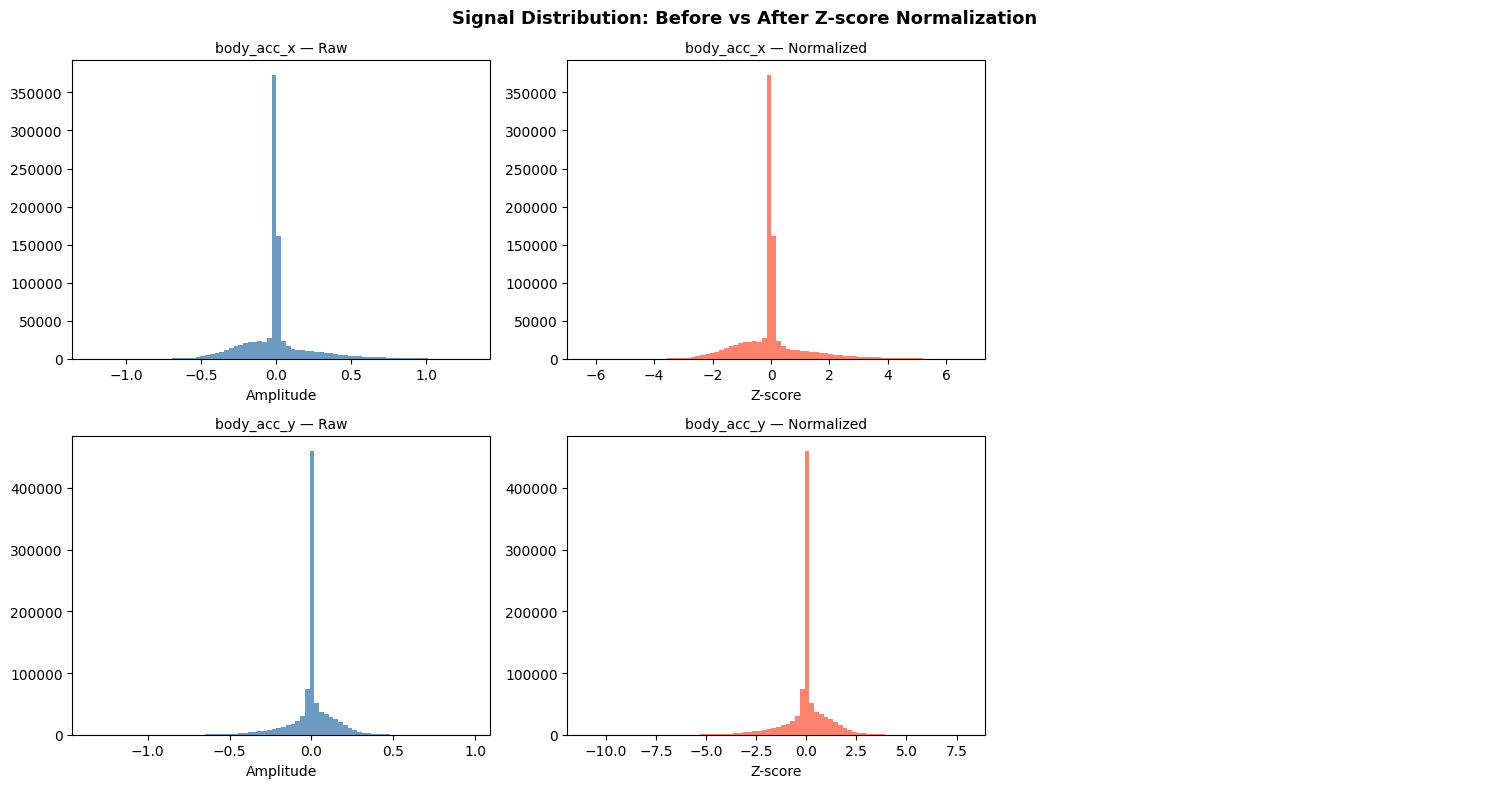

Saved: stage3_normalization_comparison.png


In [27]:
# ─── Step 3.9: Visualise Before / After Normalization ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ch_idx, ax_row in enumerate(axes):
    ch_name = SIGNAL_NAMES[ch_idx]
    raw_vals = X_raw_train[:, :, ch_idx].flatten()
    norm_vals = X_raw_train_norm[:, :, ch_idx].flatten()

    # Before
    ax_row[0].hist(raw_vals, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
    ax_row[0].set_title(f'{ch_name} — Raw', fontsize=10)
    ax_row[0].set_xlabel('Amplitude')

    # After
    ax_row[1].hist(norm_vals, bins=80, color='tomato', alpha=0.8, edgecolor='none')
    ax_row[1].set_title(f'{ch_name} — Normalized', fontsize=10)
    ax_row[1].set_xlabel('Z-score')

    ax_row[2].axis('off')  # spacer

    if ch_idx >= 1:
        break   # only show 2 channels to keep figure concise

fig.suptitle('Signal Distribution: Before vs After Z-score Normalization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stage3_normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage3_normalization_comparison.png")

In [28]:

# ─── Step 3.10: Low-Variance Feature Filtering (Pre-computed 561 Features) ───
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.0)   # remove zero-variance only
X_train_vt = vt.fit_transform(X_train_scaled)
X_test_vt  = vt.transform(X_test_scaled)

n_removed = X_train_scaled.shape[1] - X_train_vt.shape[1]
print(f"VarianceThreshold: removed {n_removed} zero-variance features.")
print(f"Features remaining: {X_train_vt.shape[1]}")

VarianceThreshold: removed 0 zero-variance features.
Features remaining: 477


In [29]:
# ─── Stage 3 Summary: Preprocessed Objects Ready for Modelling ───────────────
import textwrap

summary = """
╔══════════════════════════════════════════════════════════════════════╗
║          PREPROCESSING COMPLETE — OBJECTS READY FOR STAGES 4–6      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Classical ML (SVM / Random Forest)                                  ║
║  ─────────────────────────────────                                   ║
║  X_train_vt     {x_tr:<30} Features (UCI 561-dim)       ║
║  X_test_vt      {x_te:<30}                               ║
║  X_hand_train_sc{xh_tr:<30} Handcrafted Time+Freq feats  ║
║  X_hand_test_sc {xh_te:<30}                               ║
║  y_train_enc    {y_tr:<30} Integer labels (0–5)          ║
║  y_test_enc     {y_te:<30}                               ║
║                                                                      ║
║  LSTM (Deep Learning)                                                ║
║  ─────────────────────                                               ║
║  X_raw_train_norm {xr_tr:<28} Raw sequences               ║
║  X_raw_test_norm  {xr_te:<28}                               ║
║  y_train_ohe    {yo_tr:<30} One-hot labels                ║
║  y_test_ohe     {yo_te:<30}                               ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(
    x_tr=str(X_train_vt.shape),
    x_te=str(X_test_vt.shape),
    xh_tr=str(X_hand_train_sc.shape),
    xh_te=str(X_hand_test_sc.shape),
    y_tr=str(y_train_enc.shape),
    y_te=str(y_test_enc.shape),
    xr_tr=str(X_raw_train_norm.shape),
    xr_te=str(X_raw_test_norm.shape),
    yo_tr=str(y_train_ohe.shape),
    yo_te=str(y_test_ohe.shape)
)
print(summary)


╔══════════════════════════════════════════════════════════════════════╗
║          PREPROCESSING COMPLETE — OBJECTS READY FOR STAGES 4–6      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Classical ML (SVM / Random Forest)                                  ║
║  ─────────────────────────────────                                   ║
║  X_train_vt     (7352, 477)                    Features (UCI 561-dim)       ║
║  X_test_vt      (2947, 477)                                                  ║
║  X_hand_train_sc(7352, 144)                    Handcrafted Time+Freq feats  ║
║  X_hand_test_sc (2947, 144)                                                  ║
║  y_train_enc    (7352,)                        Integer labels (0–5)          ║
║  y_test_enc     (2947,)                                                      ║
║                                                                      ║
║  LS

In [30]:
# ─── Save Preprocessed Arrays to Disk ────────────────────────────────────────
import joblib

os.makedirs('preprocessed', exist_ok=True)

# Classical ML arrays
np.save('preprocessed/X_train_vt.npy',       X_train_vt)
np.save('preprocessed/X_test_vt.npy',        X_test_vt)
np.save('preprocessed/X_hand_train_sc.npy',  X_hand_train_sc)
np.save('preprocessed/X_hand_test_sc.npy',   X_hand_test_sc)
np.save('preprocessed/y_train_enc.npy',      y_train_enc)
np.save('preprocessed/y_test_enc.npy',       y_test_enc)

# LSTM arrays
np.save('preprocessed/X_raw_train_norm.npy', X_raw_train_norm)
np.save('preprocessed/X_raw_test_norm.npy',  X_raw_test_norm)
np.save('preprocessed/y_train_ohe.npy',      y_train_ohe)
np.save('preprocessed/y_test_ohe.npy',       y_test_ohe)

# Scalers and encoder
joblib.dump(scaler_ml,   'preprocessed/scaler_ml.pkl')
joblib.dump(scaler_hand, 'preprocessed/scaler_hand.pkl')
joblib.dump(vt,          'preprocessed/variance_threshold.pkl')
joblib.dump(le,          'preprocessed/label_encoder.pkl')

print("All preprocessed arrays and scalers saved to ./preprocessed/")
for f in sorted(os.listdir('preprocessed')):
    size_kb = os.path.getsize(f'preprocessed/{f}') / 1024
    print(f"  {f:<35} {size_kb:>8.1f} KB")

All preprocessed arrays and scalers saved to ./preprocessed/
  X_hand_test_sc.npy                    3315.5 KB
  X_hand_train_sc.npy                   8271.1 KB
  X_raw_test_norm.npy                  26523.1 KB
  X_raw_train_norm.npy                 66168.1 KB
  X_test_vt.npy                        10982.3 KB
  X_train_vt.npy                       27397.8 KB
  label_encoder.pkl                        0.4 KB
  scaler_hand.pkl                          4.0 KB
  scaler_ml.pkl                           11.8 KB
  variance_threshold.pkl                   4.1 KB
  y_test_enc.npy                          23.1 KB
  y_test_ohe.npy                         138.3 KB
  y_train_enc.npy                         57.6 KB
  y_train_ohe.npy                        344.8 KB


In [31]:
# ─── Stage 4: SVM Classifier ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

ACTIVITY_MAP = {
    1: 'Walking', 2: 'Walking Upstairs', 3: 'Walking Downstairs',
    4: 'Sitting', 5: 'Standing', 6: 'Laying'
}
CLASS_NAMES = [ACTIVITY_MAP[i] for i in sorted(ACTIVITY_MAP)]   # 0-indexed list

# ── Load arrays saved in Stage 3 ──────────────────────────────────────────────
X_train_vt      = np.load('preprocessed/X_train_vt.npy')        # UCI 561-dim
X_test_vt       = np.load('preprocessed/X_test_vt.npy')
X_hand_train_sc = np.load('preprocessed/X_hand_train_sc.npy')   # Handcrafted time+freq
X_hand_test_sc  = np.load('preprocessed/X_hand_test_sc.npy')
y_train_enc     = np.load('preprocessed/y_train_enc.npy')       # integer labels 0–5
y_test_enc      = np.load('preprocessed/y_test_enc.npy')

print("=== Data Loaded ===")
print(f"X_train_vt      : {X_train_vt.shape}")
print(f"X_test_vt       : {X_test_vt.shape}")
print(f"X_hand_train_sc : {X_hand_train_sc.shape}")
print(f"X_hand_test_sc  : {X_hand_test_sc.shape}")
print(f"y_train_enc     : {y_train_enc.shape}  | classes: {np.unique(y_train_enc)}")

=== Data Loaded ===
X_train_vt      : (7352, 477)
X_test_vt       : (2947, 477)
X_hand_train_sc : (7352, 144)
X_hand_test_sc  : (2947, 144)
y_train_enc     : (7352,)  | classes: [0 1 2 3 4 5]


In [32]:
# ─── Reusable Evaluation Helper ───────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

def evaluate_model(model, X_test, y_test, model_name="Model", class_names=CLASS_NAMES):
    y_pred = model.predict(X_test)

    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wt  = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy         : {acc*100:.2f}%")
    print(f"  F1 (macro)       : {f1_mac:.4f}")
    print(f"  F1 (weighted)    : {f1_wt:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f"stage4_cm_{model_name.replace(' ', '_').replace('(','').replace(')','')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

    return {'model': model_name, 'accuracy': acc, 'f1_macro': f1_mac, 'f1_weighted': f1_wt, 'y_pred': y_pred}

Training Linear SVM on UCI 561-dim features...
Training time: 10.0s

  Linear SVM (UCI 561-dim)
  Accuracy         : 96.34%
  F1 (macro)       : 0.9637
  F1 (weighted)    : 0.9631

                    precision    recall  f1-score   support

           Walking       0.97      1.00      0.98       496
  Walking Upstairs       0.97      0.97      0.97       471
Walking Downstairs       1.00      0.98      0.99       420
           Sitting       0.96      0.86      0.91       491
          Standing       0.89      0.97      0.93       532
            Laying       0.99      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.97      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



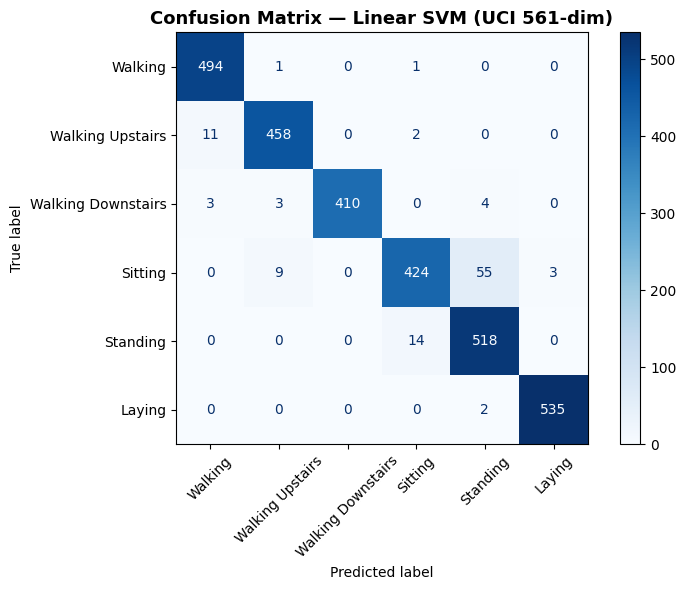

Saved: stage4_cm_Linear_SVM_UCI_561-dim.png


In [33]:
# ─── 4.1 Linear SVM — Baseline (UCI 561-dim features) ────────────────────────
from sklearn.svm import LinearSVC
import time

print("Training Linear SVM on UCI 561-dim features...")
t0 = time.time()

svm_linear = LinearSVC(C=1.0, max_iter=5000, random_state=42)
svm_linear.fit(X_train_vt, y_train_enc)

print(f"Training time: {time.time() - t0:.1f}s")

results_linear_uci = evaluate_model(svm_linear, X_test_vt, y_test_enc,
                                    model_name="Linear SVM (UCI 561-dim)")

Fitting on 30% subset to find best params...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
RandomizedSearchCV done in 0.7 min
Best params : {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
Best CV acc : 97.10%

Retraining best model on full training data...
Full retraining done in 0.2 min

  RBF SVM (UCI 561-dim)
  Accuracy         : 95.89%
  F1 (macro)       : 0.9583
  F1 (weighted)    : 0.9588

                    precision    recall  f1-score   support

           Walking       0.97      0.98      0.97       496
  Walking Upstairs       0.94      0.97      0.95       471
Walking Downstairs       0.98      0.93      0.95       420
           Sitting       0.96      0.90      0.93       491
          Standing       0.91      0.97      0.94       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.9

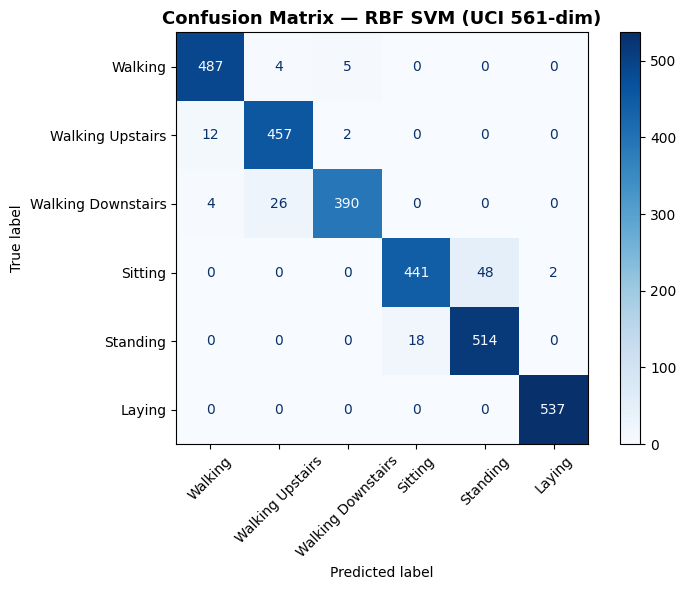

Saved: stage4_cm_RBF_SVM_UCI_561-dim.png


In [42]:
# ─── 4.2 RBF SVM with RandomizedSearchCV (UCI 561-dim features) ──────────────
import time
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# ── Reduced Parameter Grid (6 combos instead of 16) ──
param_grid = {
    'C':      [1, 10],
    'gamma':  ['scale', 0.01],
    'kernel': ['rbf']
}

# ── 3 folds instead of 5 = 40% faster ──
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ── RandomizedSearchCV instead of GridSearchCV ──
svm_rbf_gs = RandomizedSearchCV(
    SVC(probability=True, random_state=42),
    param_distributions=param_grid,
    n_iter=6,               # only 6 random combos × 3 folds = 18 fits
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,              # use all CPU cores
    random_state=42,
    verbose=1,
    refit=True
)

# ── Train on 30% subset first to find best params quickly ──
from sklearn.model_selection import train_test_split

print("Fitting on 30% subset to find best params...")
t0 = time.time()

X_small, _, y_small, _ = train_test_split(
    X_train_vt, y_train_enc,
    train_size=0.3,
    stratify=y_train_enc,
    random_state=42
)

svm_rbf_gs.fit(X_small, y_small)

print(f"RandomizedSearchCV done in {(time.time()-t0)/60:.1f} min")
print(f"Best params : {svm_rbf_gs.best_params_}")
print(f"Best CV acc : {svm_rbf_gs.best_score_*100:.2f}%")

# ── Retrain best model on FULL training data ──
print("\nRetraining best model on full training data...")
t1 = time.time()

best_svm = SVC(
    **svm_rbf_gs.best_params_,
    probability=True,
    random_state=42
)
best_svm.fit(X_train_vt, y_train_enc)

print(f"Full retraining done in {(time.time()-t1)/60:.1f} min")

# ── Evaluate ──
results_rbf_uci = evaluate_model(
    best_svm,
    X_test_vt,
    y_test_enc,
    model_name="RBF SVM (UCI 561-dim)"
)

Training RBF SVM on handcrafted time+freq features...
Training time: 4.2s

  RBF SVM (Handcrafted Features)
  Accuracy         : 90.60%
  F1 (macro)       : 0.9047
  F1 (weighted)    : 0.9058

                    precision    recall  f1-score   support

           Walking       0.87      0.87      0.87       496
  Walking Upstairs       0.93      0.88      0.91       471
Walking Downstairs       0.88      0.92      0.90       420
           Sitting       0.89      0.85      0.87       491
          Standing       0.87      0.90      0.89       532
            Laying       0.99      1.00      0.99       537

          accuracy                           0.91      2947
         macro avg       0.91      0.90      0.90      2947
      weighted avg       0.91      0.91      0.91      2947



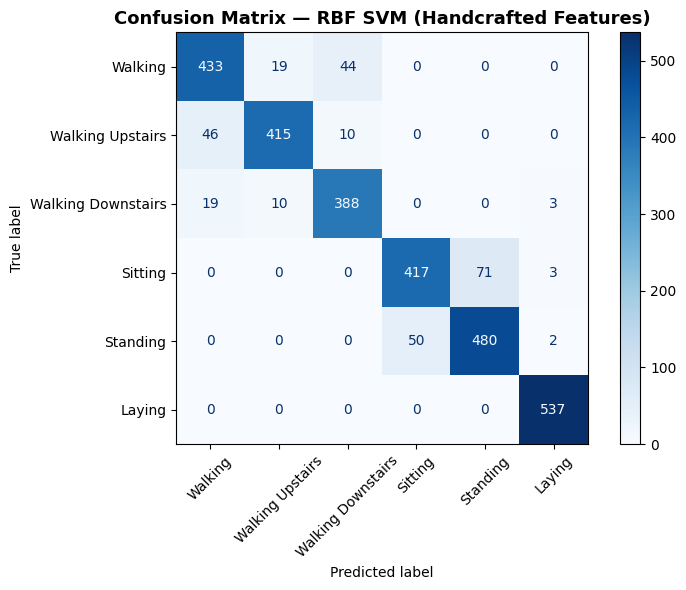

Saved: stage4_cm_RBF_SVM_Handcrafted_Features.png


In [43]:
# ─── 4.3 RBF SVM on Handcrafted Time+Freq Features ───────────────────────────
print("Training RBF SVM on handcrafted time+freq features...")

# Use best params from GridSearch as starting point (may retune if needed)
best_C     = svm_rbf_gs.best_params_['C']
best_gamma = svm_rbf_gs.best_params_['gamma']

svm_hand = SVC(C=best_C, gamma=best_gamma, kernel='rbf',
               probability=True, random_state=42)

t0 = time.time()
svm_hand.fit(X_hand_train_sc, y_train_enc)
print(f"Training time: {time.time()-t0:.1f}s")

results_rbf_hand = evaluate_model(svm_hand, X_hand_test_sc, y_test_enc,
                                   model_name="RBF SVM (Handcrafted Features)")


=== SVM Model Comparison ===
                         Model  Accuracy (%)  F1 Macro  F1 Weighted
      Linear SVM (UCI 561-dim)         96.34    0.9637       0.9631
         RBF SVM (UCI 561-dim)         95.89    0.9583       0.9588
RBF SVM (Handcrafted Features)         90.60    0.9047       0.9058


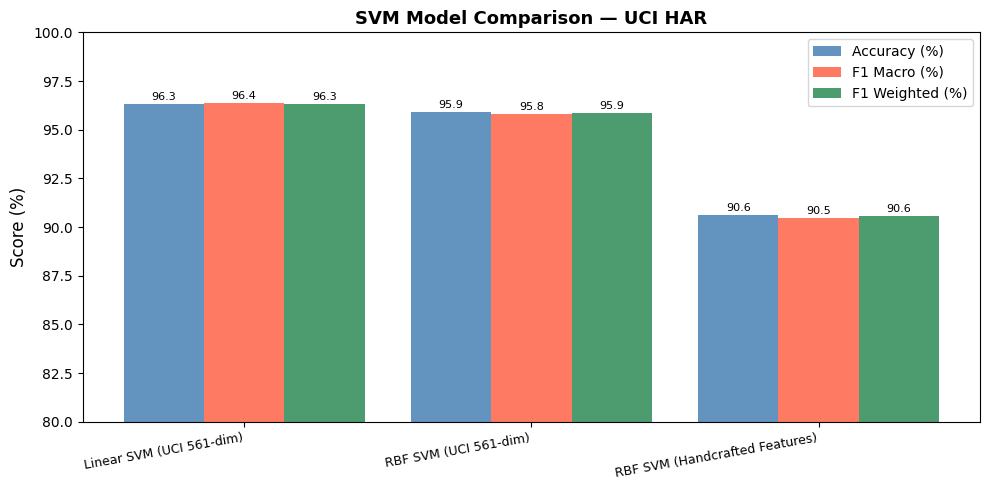

Saved: stage4_svm_comparison.png


In [44]:
# ─── 4.4 Comparison Table & Bar Chart ────────────────────────────────────────
all_results = [results_linear_uci, results_rbf_uci, results_rbf_hand]

df_results = pd.DataFrame([
    {
        'Model':         r['model'],
        'Accuracy (%)':  round(r['accuracy']*100, 2),
        'F1 Macro':      round(r['f1_macro'],   4),
        'F1 Weighted':   round(r['f1_weighted'], 4),
    }
    for r in all_results
])

print("\n=== SVM Model Comparison ===")
print(df_results.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_results))
w = 0.28

bars1 = ax.bar(x - w,   df_results['Accuracy (%)'],  w, label='Accuracy (%)',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x,       df_results['F1 Macro']*100,   w, label='F1 Macro (%)', color='tomato',     alpha=0.85)
bars3 = ax.bar(x + w,   df_results['F1 Weighted']*100,w, label='F1 Weighted (%)',color='seagreen', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], fontsize=9, rotation=10, ha='right')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(80, 100)
ax.set_title('SVM Model Comparison — UCI HAR', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f"{bar.get_height():.1f}",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('stage4_svm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage4_svm_comparison.png")

In [45]:
# ─── 4.5 Save Best SVM Model ─────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

joblib.dump(svm_rbf_gs.best_estimator_, 'models/svm_rbf_uci.pkl')
joblib.dump(svm_hand,                   'models/svm_rbf_hand.pkl')

print("Models saved:")
print("  models/svm_rbf_uci.pkl   — Best RBF SVM on UCI 561-dim features")
print("  models/svm_rbf_hand.pkl  — RBF SVM on handcrafted time+freq features")
print("\nStage 4 complete. Proceed to Stage 5 (Random Forest).")

Models saved:
  models/svm_rbf_uci.pkl   — Best RBF SVM on UCI 561-dim features
  models/svm_rbf_hand.pkl  — RBF SVM on handcrafted time+freq features

Stage 4 complete. Proceed to Stage 5 (Random Forest).


In [46]:
# ─── Download trained models to your local machine ───────────────────────────
from google.colab import files

files.download('models/svm_rbf_uci.pkl')       # Best RBF SVM (main model)
files.download('models/svm_rbf_hand.pkl')      # RBF SVM on handcrafted features

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# ─── Download scalers & encoder (needed for deployment) ──────────────────────
files.download('preprocessed/scaler_ml.pkl')          # StandardScaler for UCI features
files.download('preprocessed/variance_threshold.pkl') # VarianceThreshold
files.download('preprocessed/label_encoder.pkl')      # LabelEncoder

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>